In [5]:
import pandas as pd
from scipy import stats
from mlxtend.preprocessing import minmax_scaling
from sklearn.preprocessing import OneHotEncoder
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.read_csv("files/laptop_prices.csv")

# **Data Cleaning**

In [6]:
# Missing values check. (none)
missing_values_count = data.isnull().sum()
print(missing_values_count)


Company                 0
Product                 0
TypeName                0
Inches                  0
Ram                     0
OS                      0
Weight                  0
Price_euros             0
Screen                  0
ScreenW                 0
ScreenH                 0
Touchscreen             0
IPSpanel                0
RetinaDisplay           0
CPU_company             0
CPU_freq                0
CPU_model               0
PrimaryStorage          0
SecondaryStorage        0
PrimaryStorageType      0
SecondaryStorageType    0
GPU_company             0
GPU_model               0
dtype: int64


# **Data Scaling and  Normalization**

In [7]:
# Check for numerical columns to apply scaling or normalization.
print(data.dtypes)

Company                     str
Product                     str
TypeName                    str
Inches                  float64
Ram                       int64
OS                          str
Weight                  float64
Price_euros             float64
Screen                      str
ScreenW                   int64
ScreenH                   int64
Touchscreen                 str
IPSpanel                    str
RetinaDisplay               str
CPU_company                 str
CPU_freq                float64
CPU_model                   str
PrimaryStorage            int64
SecondaryStorage          int64
PrimaryStorageType          str
SecondaryStorageType        str
GPU_company                 str
GPU_model                   str
dtype: object


C:\Users\grekc\AppData\Local\Temp\ipykernel_35680\1045043789.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = data.select_dtypes(include=['object']).columns



Processed Data:
      Inches       Ram    Weight  Price_euros   ScreenW   ScreenH  CPU_freq  \
0  0.385542  0.096774  0.169576     0.196741  0.482619  0.597701  0.518519   
1  0.385542  0.096774  0.162095     0.122353  0.029911  0.094828  0.333333   
2  0.662651  0.096774  0.291771     0.067679  0.223929  0.224138  0.592593   
3  0.638554  0.225806  0.284289     0.398895  0.611964  0.741379  0.666667   
4  0.385542  0.096774  0.169576     0.275038  0.482619  0.597701  0.814815   

   PrimaryStorage  SecondaryStorage  Company_Apple  ...  \
0        0.058824               0.0            1.0  ...   
1        0.058824               0.0            1.0  ...   
2        0.121569               0.0            0.0  ...   
3        0.247059               0.0            1.0  ...   
4        0.121569               0.0            1.0  ...   

   GPU_model_Radeon R7 M440  GPU_model_Radeon R7 M445  \
0                       0.0                       0.0   
1                       0.0                 

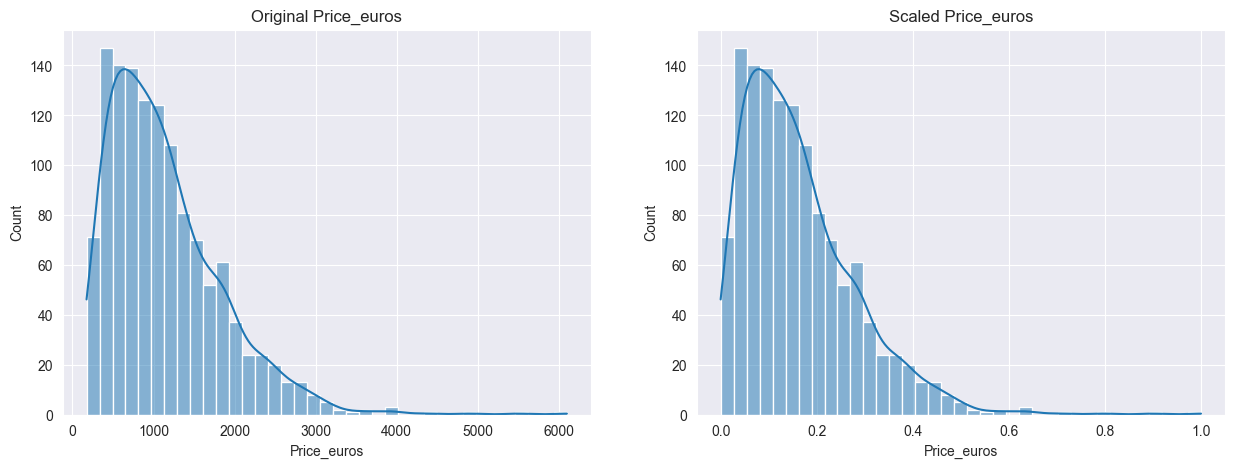

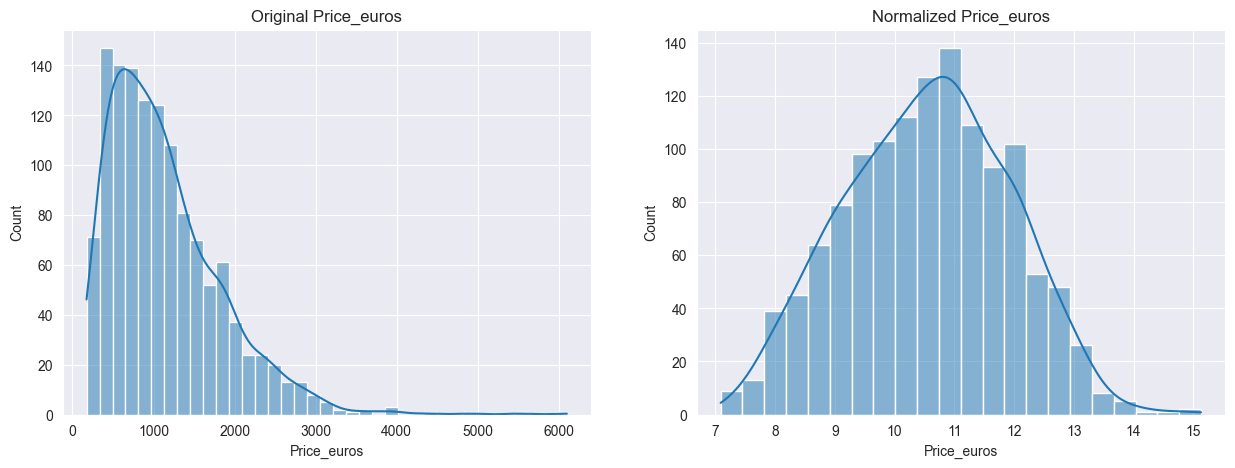

In [8]:
# Loading of data
data = pd.read_csv('files/laptop_prices.csv')

# Defining numerical and categorical features
numeric_features = ['Inches', 'Ram', 'Weight', 'Price_euros', 'ScreenW', 'ScreenH', 'CPU_freq', 'PrimaryStorage', 'SecondaryStorage']
categorical_cols = data.select_dtypes(include=['object']).columns

# Scale and Normalize
scaled_data = minmax_scaling(data[numeric_features], columns=numeric_features)
normalized_data = pd.DataFrame({col: stats.boxcox(data[col] + 1)[0] for col in numeric_features})

# Combine scaled data with the original DataFrame
data_scaled = data.copy()
data_scaled[numeric_features] = scaled_data
data_normalized = data.copy()
data_normalized[numeric_features] = normalized_data

# Encoding categorical columns using OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, drop='first')
encoded_cols = pd.DataFrame(encoder.fit_transform(data_scaled[categorical_cols]), 
                            columns=encoder.get_feature_names_out(categorical_cols))

# Combine scaled numeric and encoded categorical data
processed_data = pd.concat([data_scaled[numeric_features], encoded_cols], axis=1)

# Save
processed_data.to_csv('files/processed_data.csv', index=False)

print("\nProcessed Data:\n", processed_data.head())

# Visualization
def plot_distribution(original, transformed, title_original, title_transformed):
    fig, ax = plt.subplots(1, 2, figsize=(15, 5))
    sns.histplot(original, ax=ax[0], kde=True)
    ax[0].set_title(title_original)
    sns.histplot(transformed, ax=ax[1], kde=True)
    ax[1].set_title(title_transformed)
    plt.show()

# Plot original vs. scaled and normalized 'Price_euros'
plot_distribution(data['Price_euros'], data_scaled['Price_euros'], "Original Price_euros", "Scaled Price_euros")
plot_distribution(data['Price_euros'], data_normalized['Price_euros'], "Original Price_euros", "Normalized Price_euros")
